# Aprendizaje Supervisado - Tema 3: Extracción de características

**Fecha:** July 14, 2026  
**Autor:** Omar Recalde 
**Repositorio:** https://github.com/OmaRecalde/machinelearning2026

## Contenido:

* **Estadísticos unidimensionales:** (conceptos básicos, variables, análisis cualitativo y cuantitativo)[cite: 8]
* **Procesado de imagen:** (canales de color, transformaciones de intensidad y geométricas)[cite: 8]
* **Segmentación de imágenes:** (thresholding, Otsu, detección de bordes, crecimiento de regiones)[cite: 8]
* **Descriptores de forma y textura:** (descriptores geométricos, GLCM, SIFT, HOG, LBP)[cite: 8]

---

## 1.1 Conceptos Básicos

* **Población:** Es el conjunto de ítems (instancias, ocurrencias, individuos, sujetos, elementos, filas, etc.) que se desea estudiar, analizar o sobre el que se quiere extraer una serie de conclusiones.
* **Muestra:** Corresponde a cualquier subconjunto de la población. Es de vital importancia que la muestra sea representativa de la población mediante un muestreo aleatorio.
* **Inferencia Estadística:** Proceso de razonamiento por el que se obtienen conclusiones (con un margen de error conocido) sobre la población a partir del análisis realizado sobre el conjunto muestra.

## 1.2 Tipos de Variables

Una **variable estadística** es cada una de las cualidades que poseen los individuos de una población (valor de una propiedad o atributo).

* **Cualitativas (Categorías no numéricas):**
  * **Nominales:** Sin criterio de orden (ej. sexo, estado civil).
  * **Ordinales:** Admiten un criterio de orden (ej. nivel de estudio, satisfacción del cliente).
* **Cuantitativas (Valores numéricos):**
  * **Discretas:** Valores finitos y contables (ej. número de hijos, número de empleados).
  * **Continuas:** Valores infinitos en un rango continuo (ej. estatura, peso).

## 1.3 Análisis de Variables Cualitativas

In [1]:
# Creación aleatoria de datos
import numpy as np
import random

random.seed(42)

nivel_estudios = []
nivel_estudios.extend(['Secundaria'] * 110)
nivel_estudios.extend(['Bachillerato'] * 172)
nivel_estudios.extend(['Grado'] * 145)
nivel_estudios.extend(['Master'] * 52)
nivel_estudios.extend(['Doctorado'] * 21)

nivel_estudios = np.random.permutation(nivel_estudios)
print(nivel_estudios)

['Master' 'Bachillerato' 'Grado' 'Secundaria' 'Grado' 'Secundaria'
 'Master' 'Grado' 'Doctorado' 'Master' 'Bachillerato' 'Grado' 'Master'
 'Grado' 'Grado' 'Master' 'Grado' 'Secundaria' 'Secundaria' 'Bachillerato'
 'Bachillerato' 'Grado' 'Bachillerato' 'Secundaria' 'Secundaria'
 'Bachillerato' 'Secundaria' 'Bachillerato' 'Master' 'Grado'
 'Bachillerato' 'Bachillerato' 'Doctorado' 'Grado' 'Bachillerato'
 'Secundaria' 'Secundaria' 'Grado' 'Master' 'Bachillerato' 'Bachillerato'
 'Secundaria' 'Bachillerato' 'Secundaria' 'Grado' 'Grado' 'Bachillerato'
 'Doctorado' 'Master' 'Bachillerato' 'Grado' 'Secundaria' 'Grado'
 'Bachillerato' 'Secundaria' 'Doctorado' 'Bachillerato' 'Grado' 'Grado'
 'Bachillerato' 'Secundaria' 'Doctorado' 'Grado' 'Bachillerato' 'Grado'
 'Grado' 'Bachillerato' 'Grado' 'Bachillerato' 'Grado' 'Master'
 'Bachillerato' 'Bachillerato' 'Secundaria' 'Secundaria' 'Bachillerato'
 'Bachillerato' 'Bachillerato' 'Bachillerato' 'Grado' 'Bachillerato'
 'Secundaria' 'Bachillerato' 'Sec

['Bachillerato' 'Doctorado' 'Grado' 'Master' 'Secundaria'] [172  21 145  52 110]


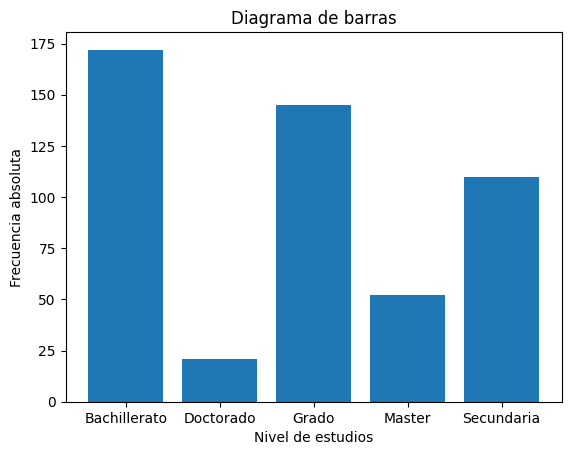

In [2]:
# DIAGRAMA DE BARRAS
import matplotlib.pyplot as plt

estudios, frecuencia = np.unique(nivel_estudios, return_counts=True)
print(estudios, frecuencia)

plt.ylabel('Frecuencia absoluta')
plt.xlabel('Nivel de estudios')
plt.title('Diagrama de barras')
plt.bar(estudios, frecuencia)
plt.show()

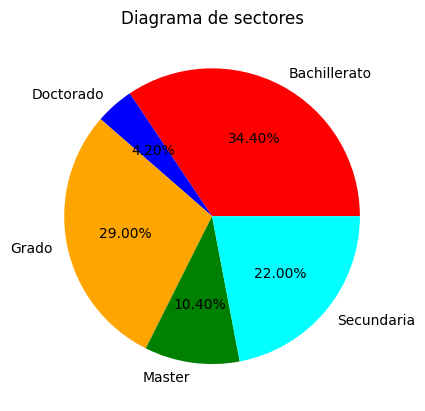

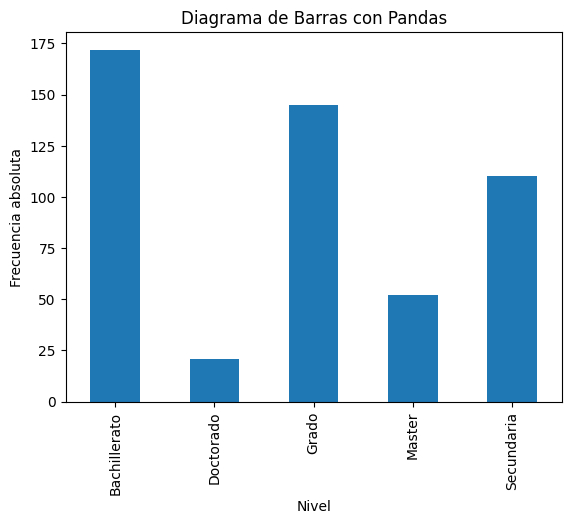

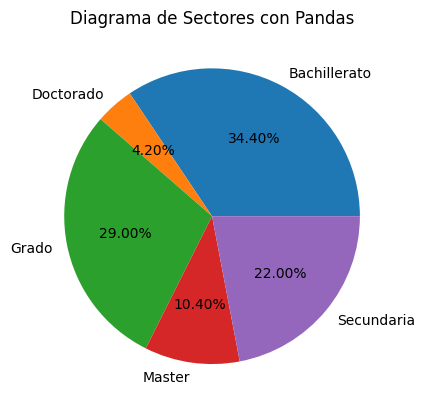

In [3]:
# DIAGRAMA DE SECTORES
colores = ['red', 'blue', 'orange', 'green', 'cyan']
plt.pie(frecuencia, labels=estudios, colors=colores, autopct='%1.2f%%')
plt.title('Diagrama de sectores')
plt.show()

# Tarea: implementar con pandas esta información
import pandas as pd

df_estudios = pd.DataFrame({'Nivel': estudios, 'Frecuencia': frecuencia})
df_estudios.plot(kind='bar', x='Nivel', y='Frecuencia', legend=False, title='Diagrama de Barras con Pandas')
plt.ylabel('Frecuencia absoluta')
plt.show()

df_estudios.set_index('Nivel').plot(kind='pie', y='Frecuencia', autopct='%1.2f%%', legend=False, title='Diagrama de Sectores con Pandas')
plt.ylabel('')
plt.show()

## 1.4 Análisis de Variables Cuantitativas

* **Medidas de tendencia central:** Media ($\bar{x}$), Mediana ($Me$) y Moda ($Mo$).
* **Medidas de posición:** Cuartiles ($Q_1, Q_2, Q_3$), Rango Intercuartílico ($RIC = Q_3 - Q_1$), Límites de outliers ($L_s = Q_3 + 1.5 \cdot RIC$, $L_i = Q_1 - 1.5 \cdot RIC$).
* **Medidas de dispersión:** Varianza ($\sigma^2$), Desviación típica ($\sigma$).
* **Medidas de distribución:** Asimetría ($A$) y Curtosis ($K$).

In [5]:
!pip install scipy opencv-python scikit-image tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 21.1 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 MB 29.0 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 12.6 MB/s eta 0:00:00MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-image]0m 5/6 [scikit-image]o]


[   0.5   23.     0.3    4.5    0.3    0.5  -10.   -11.    13.    19.
    1.     9.   -28.   -50.    60.  -100. ]
media: -4.2437499999999995
mediana: 0.5
moda: 0.3
RIC: 20.25
limite inferior: -40.625
limite superior: 40.375


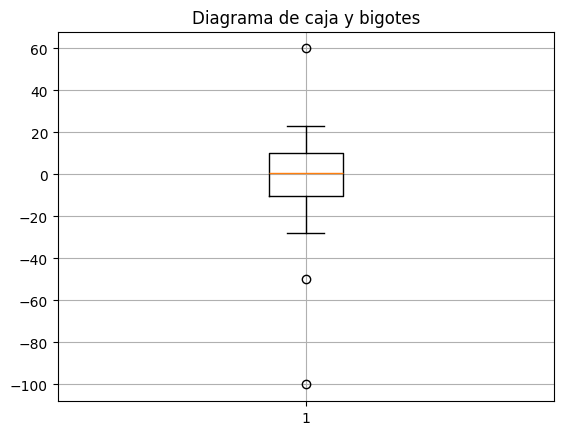

Desviación típica: 33.521242681880096
Varianza: 1123.6737109375
Asimetría: -1.1302
Curtosis: 2.2858
Distribución Leptocúrtica


In [6]:
# Creación aleatoria de datos
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5, -10, -11, 13, 19, 1, 9, -28, -50, 60, -100])
print(X)

# Medidas de tendencia central
from scipy import stats

media = np.mean(X)
mediana = np.median(X)
moda = stats.mode(X, keepdims=True)

print('media:', media)
print('mediana:', mediana)
print('moda:', moda.mode[0])

# Medidas de posición
Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5 * RIC
lim_sup = Q3 + 1.5 * RIC

print('RIC:', RIC)
print('limite inferior:', lim_inf)
print('limite superior:', lim_sup)

# Dibuja el diagrama de caja y bigotes
plt.boxplot(X)
plt.grid(True)
plt.title("Diagrama de caja y bigotes")
plt.show()

# Medidas de dispersión
desvest = np.std(X)
print('Desviación típica:', desvest)
print('Varianza:', desvest**2)

# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True)

print('Asimetría:', np.round(asimetria, 4))
print('Curtosis:', np.round(curtosis, 4))

if curtosis > 0:
    print('Distribución Leptocúrtica')
elif curtosis < 0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

In [8]:
!pip install scikit-learn scipy seaborn opencv-python scikit-image tabulate matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 11.0 MB/s eta 0:00:00m eta 0:00:0136m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]


In [9]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint

iris = datasets.load_iris()
# pprint(iris)

petal_length = iris.data[:, 2] # Longitud del pétalo
sepal_width = iris.data[:, 1]  # Ancho del sépalo

# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
asim_petal = stats.skew(petal_length)
print(f'Asimetría (longitud del pétalo): {asim_petal:.4f}')
print('La variable presenta una asimetría negativa (sesgo hacia la izquierda).')

# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según su curtosis?
kurt_sepal = stats.kurtosis(sepal_width, fisher=True)
print(f'Curtosis (ancho del sépalo): {kurt_sepal:.4f}')
print('La distribución es leptocúrtica (K > 0).')

Asimetría (longitud del pétalo): -0.2721
La variable presenta una asimetría negativa (sesgo hacia la izquierda).
Curtosis (ancho del sépalo): 0.1810
La distribución es leptocúrtica (K > 0).


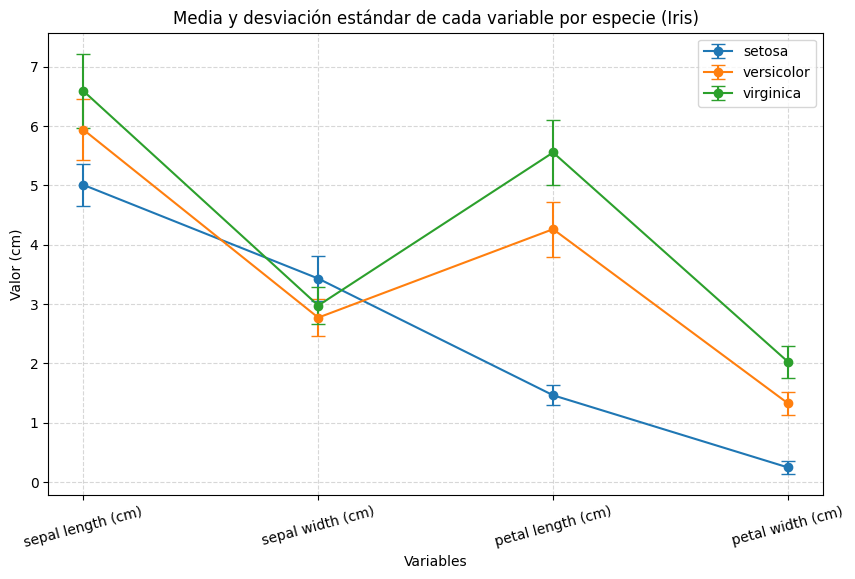

In [10]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la clase y representarlo en un gráfico (plt.errorbar)

feature_names = iris.feature_names
target_names = iris.target_names
X_data = iris.data
y_data = iris.target

plt.figure(figsize=(10, 6))

for i, target in enumerate(target_names):
    class_data = X_data[y_data == i]
    means = np.mean(class_data, axis=0)
    stds = np.std(class_data, axis=0)
    
    plt.errorbar(feature_names, means, yerr=stds, fmt='-o', capsize=5, label=target)

plt.title('Media y desviación estándar de cada variable por especie (Iris)')
plt.xlabel('Variables')
plt.ylabel('Valor (cm)')
plt.xticks(rotation=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.show()

---
## 2. Procesado de Imagen y Transformaciones

En esta sección exploramos el manejo de imágenes digitales como matrices numéricas, conversión de espacios de color (RGB a escala de grises), transformaciones de intensidad (ecualización de histograma) y transformaciones geométricas 2D (traslación, rotación y escalado).

Dimensiones de la imagen RGB: (512, 512, 3)
Dimensiones en escala de grises: (512, 512)
Rango de intensidad: Min=0, Max=255


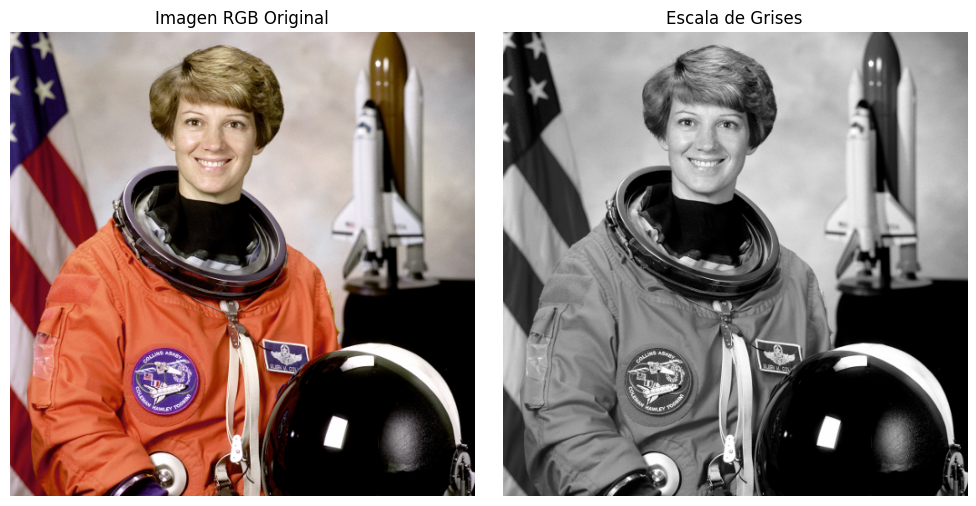

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, exposure

# Cargar una imagen de prueba desde skimage
image_rgb = data.astronaut()

# Convertir a escala de grises usando fórmula ponderada: Y = 0.299 R + 0.587 G + 0.114 B
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

print(f"Dimensiones de la imagen RGB: {image_rgb.shape}")
print(f"Dimensiones en escala de grises: {image_gray.shape}")
print(f"Rango de intensidad: Min={image_gray.min()}, Max={image_gray.max()}")

# Mostrar ambas imágenes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_rgb)
axes[0].set_title('Imagen RGB Original')
axes[0].axis('off')

axes[1].imshow(image_gray, cmap='gray')
axes[1].set_title('Escala de Grises')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## 3. Segmentación de Imágenes
Técnicas para separar objetos del fondo mediante umbralización (Thresholding global y método de Otsu) y detección de bordes con el algoritmo de Canny.

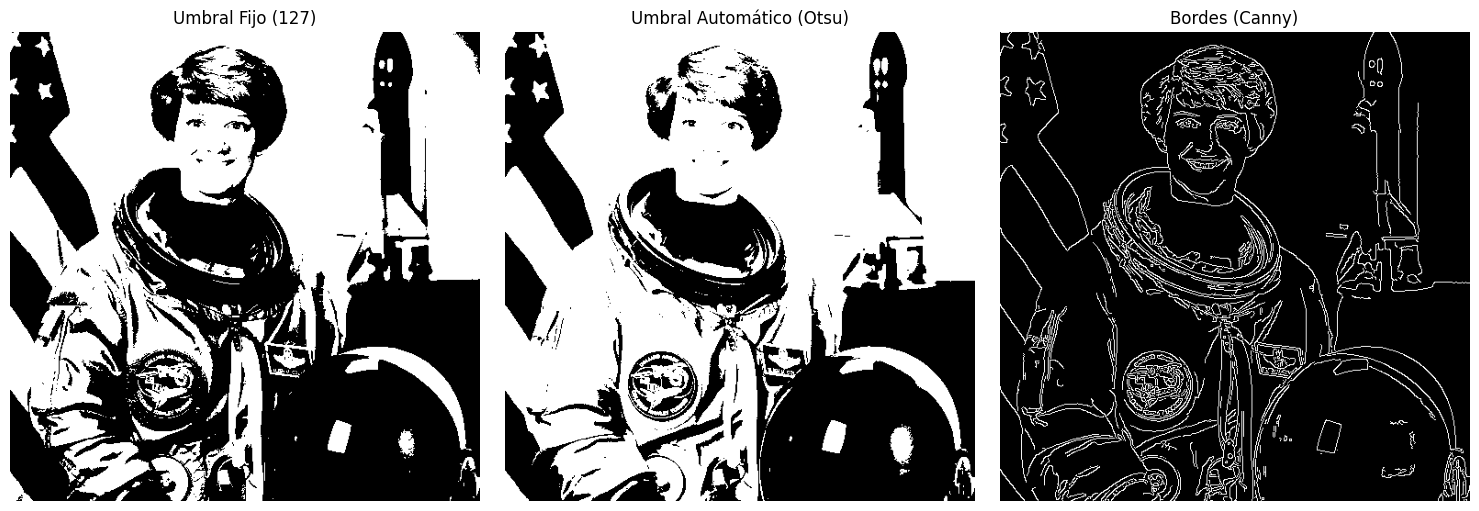

In [16]:
# 1. Umbralización Global Simple vs Otsu
_, thresh_global = cv2.threshold(image_gray, 127, 255, cv2.THRESH_BINARY)
_, thresh_otsu = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Detección de Bordes Canny
edges_canny = cv2.Canny(image_gray, threshold1=100, threshold2=200)

# Visualización de la segmentación
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(thresh_global, cmap='gray')
axes[0].set_title('Umbral Fijo (127)')
axes[0].axis('off')

axes[1].imshow(thresh_otsu, cmap='gray')
axes[1].set_title('Umbral Automático (Otsu)')
axes[1].axis('off')

axes[2].imshow(edges_canny, cmap='gray')
axes[2].set_title('Bordes (Canny)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

---
## 4. Descriptores de Forma
Extracción de propiedades geométricas (área, perímetro, excentricidad) y Momentos Invariantes de Hu sobre los contornos extraídos de la imagen.

In [17]:
from skimage.measure import label, regionprops
from tabulate import tabulate

# Etiquetado de regiones binarias
label_img = label(thresh_otsu)
regions = regionprops(label_img)

# Obtener métricas del objeto principal más grande
if regions:
    largest_region = max(regions, key=lambda r: r.area)
    
    # Momentos de Hu con OpenCV
    moments = cv2.moments(thresh_otsu)
    hu_moments = cv2.HuMoments(moments).flatten()

    tabla_forma = [
        ["Área (px)", largest_region.area],
        ["Perímetro (px)", round(largest_region.perimeter, 2)],
        ["Excentricidad", round(largest_region.eccentricity, 4)],
        ["Solidez", round(largest_region.solidity, 4)],
        ["Hu Moment 1", round(hu_moments[0], 6)],
        ["Hu Moment 2", round(hu_moments[1], 6)]
    ]
    print(tabulate(tabla_forma, headers=["Descriptor de Forma", "Valor"], tablefmt="fancy_grid"))

╒═══════════════════════╤═══════════════╕
│ Descriptor de Forma   │         Valor │
╞═══════════════════════╪═══════════════╡
│ Área (px)             │ 154951        │
├───────────────────────┼───────────────┤
│ Perímetro (px)        │  13502.4      │
├───────────────────────┼───────────────┤
│ Excentricidad         │      0.6627   │
├───────────────────────┼───────────────┤
│ Solidez               │      0.6221   │
├───────────────────────┼───────────────┤
│ Hu Moment 1           │      0.000998 │
├───────────────────────┼───────────────┤
│ Hu Moment 2           │      0        │
╘═══════════════════════╧═══════════════╛


---
## 5. Descriptores de Textura y Puntos de Interés (HOG, LBP, SIFT)
Análisis de patrones de textura mediante Local Binary Patterns (LBP) y Histogram of Oriented Gradients (HOG) para extracción de características avanzadas.

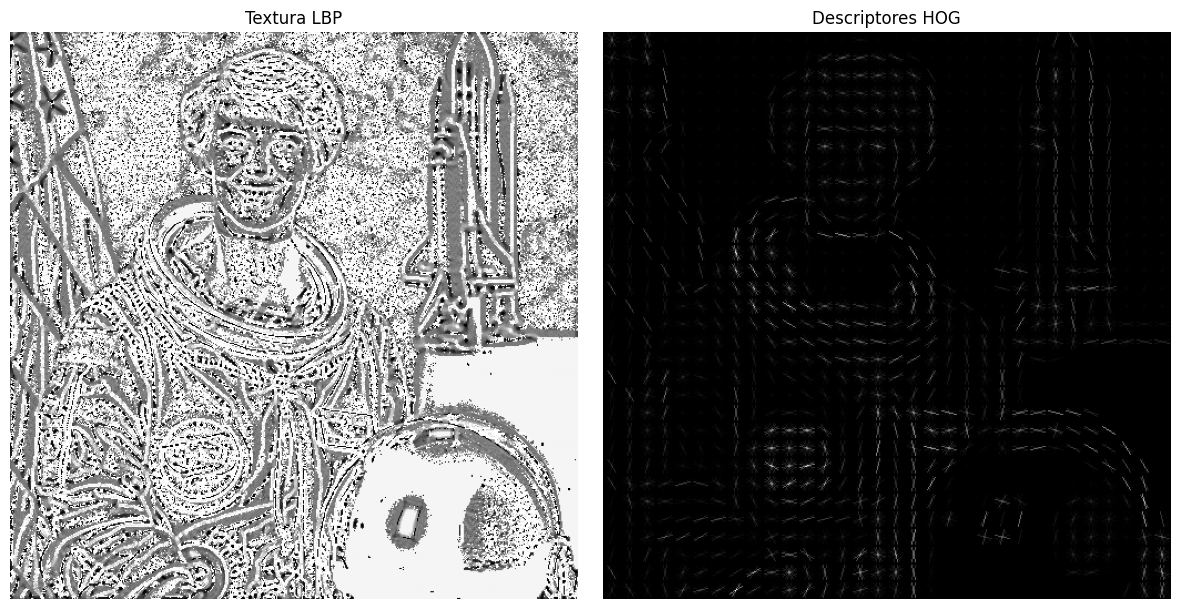

In [18]:
from skimage.feature import local_binary_pattern, hog

# 1. Local Binary Patterns (LBP)
radius = 3
n_points = 8 * radius
lbp = local_binary_pattern(image_gray, n_points, radius, method="uniform")

# 2. Histogram of Oriented Gradients (HOG)
hog_features, hog_image = hog(
    image_gray, 
    orientations=8, 
    pixels_per_cell=(16, 16), 
    cells_per_block=(1, 1), 
    visualize=True
)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(lbp, cmap='gray')
axes[0].set_title('Textura LBP')
axes[0].axis('off')

axes[1].imshow(hog_image, cmap='gray')
axes[1].set_title('Descriptores HOG')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## 6. Síntesis y Matriz Comparativa del Tema 3

| Fase / Técnica | Propósito Principal | Salida / Métrica | Aplicación Práctica |
| :--- | :--- | :--- | :--- |
| **Estadística Descriptiva** | Caracterización de datos tabulares | Media, Curtosis, Asimetría | Análisis previo y balanceo de datos |
| **Transformaciones 2D** | Normalización espacial e intensidad | Histograma ecualizado, Rotación | Aumento de datos (Data Augmentation) |
| **Segmentación (Otsu/Canny)** | Aislamiento de Objetos / Regiones | Máscara binaria, Mapa de bordes | Separación de ROI (Región de Interés) |
| **Descriptores de Forma** | Cuantificación de geometría | Momentos de Hu, Excentricidad | Clasificación de formas geométricas |
| **Descriptores de Textura** | Patrones locales de intensidad | Vetor HOG, Matriz LBP | Reconocimiento de objetos y rostros |

### Conclusiones Técnicas
1. **Flujo Integrado:** La extracción de características transforma datos crudos (imágenes/tablas) en vectores numéricos aptos para algoritmos de Aprendizaje Supervisado.
2. **Complementariedad:** Los descriptores de forma (Hu) son invariantes a escala y rotación, mientras que los de textura (HOG/LBP) capturan variaciones de iluminación y patrones complejos.